# GC10-DET steel defects - what the dataset contains, and where its labels disagree

**Arkon Manufacturing AI | Module: CV Object Detection | Department: Stamping**

This is the sixth Arkon model module and the fourth in `visual_inspection`. The
three that came before it all return one answer per frame: casting says defective
or sound, NEU names one of six defect types, MVTec scores how unusual a part is.
None of them says *where*. `docs/Model_Card_NEU_Surface.md` limitation 3 names
that gap and names this module as the place it closes.

So this notebook is not looking for another classification target. It is checking
whether the 3,564 boxes this dataset ships are good enough to train a detector on,
and the answer turns out to need several qualifications.

Everything below is measured from the files. The dataset's own README and its
class-key spreadsheet are treated as claims to be checked, not as facts.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


In [2]:
import re
import xml.etree.ElementTree as ET
import zipfile
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from PIL import Image

RAW = Path('../../../data/06_gc10/raw').resolve()
ANNOTATION_DIR = RAW / 'lable'          # the dataset's own spelling, kept as shipped
CLASS_KEY_XLSX = RAW / 'Defects Description.xlsx'
CLASS_FOLDERS = [str(n) for n in range(1, 11)]

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

print(f'raw data   : {RAW}')
print(f'annotations: {ANNOTATION_DIR.name}/  ({len(list(ANNOTATION_DIR.glob("*.xml")))} xml files)')

raw data   : D:\-PROJECTS\--Portfolio\arkon-manufacturing-ai\data\06_gc10\raw
annotations: lable/  (2294 xml files)


## 2. One scan, and everything after it is a query

The images sit in ten numbered folders and the boxes sit in one flat annotation
folder keyed by file stem. This cell reads both once into a single table, and
every question after it is a query against that table rather than another walk
of 935 MB.

Two things are recorded per image that a naive scan would lose: **every** folder
the file appears in, not the first one found, and the classes named by its boxes
as distinct from the folder it was filed under. Section 5 is about the gap
between those two.

In [3]:
def scan_folders():
    """Map every image stem to the list of class folders that contain a copy of it."""
    stems = defaultdict(list)
    files = {}
    for folder in CLASS_FOLDERS:
        for path in sorted((RAW / folder).iterdir()):
            if path.is_file():
                stems[path.stem].append(folder)
                files.setdefault(path.stem, path)
    return stems, files


def scan_annotations():
    """Parse every VOC file into one row per box, plus one row per image with no box."""
    rows, per_image = [], {}
    for path in sorted(ANNOTATION_DIR.glob('*.xml')):
        root = ET.parse(path).getroot()
        size = root.find('size')
        width, height = int(size.find('width').text), int(size.find('height').text)
        objects = root.findall('object')
        per_image[path.stem] = {
            'width': width, 'height': height,
            'depth': int(size.find('depth').text),
            'xml_folder': (root.find('folder').text or '').strip(),
            'n_boxes': len(objects),
        }
        for obj in objects:
            box = obj.find('bndbox')
            x0, y0 = float(box.find('xmin').text), float(box.find('ymin').text)
            x1, y1 = float(box.find('xmax').text), float(box.find('ymax').text)
            rows.append({
                'stem': path.stem, 'tag': (obj.find('name').text or '').strip(),
                'xmin': x0, 'ymin': y0, 'xmax': x1, 'ymax': y1,
                'width': width, 'height': height,
            })
    return pd.DataFrame(rows), pd.DataFrame(per_image).T


folder_of_stem, image_file = scan_folders()
boxes, images = scan_annotations()
images.index.name = 'stem'

print(f'image files in the ten class folders : {sum(len(v) for v in folder_of_stem.values()):,}')
print(f'distinct image stems                 : {len(folder_of_stem):,}')
print(f'annotation files                     : {len(images):,}')
print(f'boxes                                : {len(boxes):,}')

image files in the ten class folders : 2,312
distinct image stems                 : 2,300
annotation files                     : 2,294
boxes                                : 3,564


## 3. Do the image folders and the annotation folder agree

Three separate disagreements, and the count of each matters later because two of
them decide which images can be used at all.

In [4]:
duplicated = {stem: folders for stem, folders in folder_of_stem.items() if len(folders) > 1}
missing_annotation = sorted(set(folder_of_stem) - set(images.index))
orphan_annotation = sorted(set(images.index) - set(folder_of_stem))
empty_annotation = sorted(images.index[images['n_boxes'] == 0])

print(f'stems filed in more than one class folder : {len(duplicated)}')
print(f'images with no annotation file            : {len(missing_annotation)}')
print(f'annotation files with no image            : {len(orphan_annotation)}')
print(f'annotation files carrying zero boxes      : {len(empty_annotation)}')
print()
print('the double-filed stems, with the folders they sit in and what their boxes say:')
for stem in sorted(duplicated):
    tags = sorted(boxes.loc[boxes['stem'] == stem, 'tag'].unique())
    print(f'  {stem}  folders {duplicated[stem]}  boxes {tags}')

stems filed in more than one class folder : 12
images with no annotation file            : 6
annotation files with no image            : 0
annotation files carrying zero boxes      : 2

the double-filed stems, with the folders they sit in and what their boxes say:
  img_01_425503100_00018  folders ['3', '7']  boxes ['3_yueyawan', '7_yiwu', '8_yahen']
  img_02_425392000_00984  folders ['7', '8']  boxes ['4_shuiban', '7_yiwu']
  img_03_425506300_00018  folders ['1', '2']  boxes ['1_chongkong', '2_hanfeng']
  img_03_436068500_00002  folders ['7', '8']  boxes ['7_yiwu', '8_yahen']
  img_04_425503600_00017  folders ['2', '3']  boxes ['2_hanfeng', '3_yueyawan']
  img_06_3436814000_00687  folders ['9', '10']  boxes ['10_yaozhe']
  img_06_425502900_00052  folders ['1', '2']  boxes ['1_chongkong', '2_hanfeng']
  img_06_425505500_00052  folders ['2', '8']  boxes ['2_hanfeng']
  img_07_425391800_00054  folders ['1', '6']  boxes ['1_chongkong', '2_hanfeng']
  img_07_425502900_00052  folders ['1', 

In [5]:
print('images with no annotation file:')
for stem in missing_annotation:
    print(f'  {stem}  filed under folder {folder_of_stem[stem]}')
print()
print('annotation files carrying zero boxes:')
for stem in empty_annotation:
    print(f'  {stem}  filed under folder {folder_of_stem.get(stem, "?")}')

unusable = sorted(set(missing_annotation) | set(empty_annotation))
print()
print(f'{len(unusable)} of {len(folder_of_stem):,} images carry no box at all, from two separate causes.')
print(f'{len(folder_of_stem) - len(unusable):,} images are left with at least one box.')

images with no annotation file:
  img_05_425382900_00002  filed under folder ['9']
  img_06_425614600_00429  filed under folder ['10']
  img_06_425614600_00438  filed under folder ['10']
  img_07_3436814000_00020  filed under folder ['10']
  img_07_436164700_01539  filed under folder ['10']
  img_08_4406743300_00407  filed under folder ['6']

annotation files carrying zero boxes:
  img_02_4406772100_00175  filed under folder ['4']
  img_06_3402617700_00988  filed under folder ['7']

8 of 2,300 images carry no box at all, from two separate causes.
2,292 images are left with at least one box.


**These eight are dropped rather than counted as background, and the reason is
the difference between the two causes.** An image with an empty annotation could
in principle mean "somebody looked and found nothing", which would make it a
sound sheet and the only negative examples this dataset has. An image with no
annotation file means nobody recorded an answer. The two are indistinguishable
from here, both were filed under a defect class by whoever built the dataset, and
treating either as clean steel would be inventing a label. Notebook 02 drops all
eight and says so.

## 4. Image properties, measured on all of them

Detection cost scales with pixels, so the input size is a decision this notebook
has to inform rather than leave to the modelling notebook.

In [6]:
size_counts = images.groupby(['width', 'height']).size().rename('images')
print(size_counts.to_string())
print()
print(f'depth field values : {dict(Counter(images["depth"]))}')

sample = [Image.open(image_file[stem]) for stem in list(image_file)[:200]]
print(f'PIL modes over 200 files : {dict(Counter(im.mode for im in sample))}')
print(f'PIL sizes over 200 files : {dict(Counter(im.size for im in sample))}')
for im in sample:
    im.close()

width  height
2048   1000      2294

depth field values : {1: 2294}


PIL modes over 200 files : {'L': 200}
PIL sizes over 200 files : {(2048, 1000): 200}


**Every image is 2048 x 1000 and single-channel.** That is 2.05 megapixels, ten
times a NEU crop and eight times an MVTec part, and it is one uniform size, so no
letterboxing or aspect-ratio bucketing is needed. The single channel matters for
the model: every detector with pretrained weights in `torchvision` expects three,
so the channel has to be repeated, and that repetition is a real thing to record
rather than a detail, because it means two thirds of the input carries no
information the first convolution has not already seen.

## 5. The class key, and whether the files agree with it

The dataset ships `Defects Description.xlsx` beside the folders. It names the ten
classes in Chinese and English, gives the tag used in the annotations, and
**declares a box count per class**. That last column is the useful one: it is an
independent statement of what the annotations should contain, so it can be
checked rather than trusted.

`openpyxl` is not in this project's environment and adding a dependency to read
one table is not worth it. An `.xlsx` is a zip of XML, so the cell below reads it
with the standard library.

In [7]:
def read_class_key(path):
    """Read the shipped class-key sheet without adding an Excel dependency."""
    ns = '{http://schemas.openxmlformats.org/spreadsheetml/2006/main}'
    with zipfile.ZipFile(path) as archive:
        shared = [''.join(t.text or '' for t in si.iter(ns + 't'))
                  for si in ET.fromstring(archive.read('xl/sharedStrings.xml')).findall(ns + 'si')]
        sheet = ET.fromstring(archive.read('xl/worksheets/sheet1.xml'))
        cells = {}
        for cell in sheet.iter(ns + 'c'):
            value = cell.find(ns + 'v')
            if value is None:
                continue
            text = value.text
            cells[cell.get('r')] = shared[int(text)] if cell.get('t') == 's' else text
    rows = []
    for row in range(4, 14):                       # the ten class rows of the sheet
        rows.append({
            'class_id': int(cells[f'C{row}']),
            'english': cells[f'E{row}'].strip(),
            'tag': cells[f'F{row}'].strip(),
            'declared_boxes': int(cells[f'G{row}']),
        })
    return pd.DataFrame(rows)


class_key = read_class_key(CLASS_KEY_XLSX)
print(class_key.to_string(index=False))
print()
print(f'declared boxes in total : {class_key["declared_boxes"].sum():,}')
print(f'boxes in the annotations: {len(boxes):,}')

 class_id       english         tag  declared_boxes
        1 punching_hole 1_chongkong             329
        2  welding_line   2_hanfeng             513
        3  crescent_gap  3_yueyawan             265
        4    water_spot   4_shuiban             354
        5      oil_spot    5_youban             569
        6     silk_spot     6_siban             884
        7     inclusion      7_yiwu             347
        8    rolled_pit     8_yahen              85
        9        crease    9_zhehen              74
       10 waist folding   10_yaozhe             150

declared boxes in total : 3,570
boxes in the annotations: 3,564


In [8]:
found = boxes['tag'].value_counts()
check = class_key.copy()
check['found_boxes'] = check['tag'].map(found).fillna(0).astype(int)
check['difference'] = check['found_boxes'] - check['declared_boxes']
print(check[['class_id', 'english', 'tag', 'declared_boxes', 'found_boxes', 'difference']]
      .to_string(index=False))

unknown = sorted(set(found.index) - set(class_key['tag']))
print()
print(f'tags in the annotations that the key does not list: {unknown}')
for tag in unknown:
    print(f'  {tag!r}: {int(found[tag])} boxes on '
          f'{boxes.loc[boxes["tag"] == tag, "stem"].nunique()} image(s)')

 class_id       english         tag  declared_boxes  found_boxes  difference
        1 punching_hole 1_chongkong             329          329           0
        2  welding_line   2_hanfeng             513          513           0
        3  crescent_gap  3_yueyawan             265          265           0
        4    water_spot   4_shuiban             354          354           0
        5      oil_spot    5_youban             569          569           0
        6     silk_spot     6_siban             884          884           0
        7     inclusion      7_yiwu             347          347           0
        8    rolled_pit     8_yahen              85           85           0
        9        crease    9_zhehen              74           74           0
       10 waist folding   10_yaozhe             150           12        -138

tags in the annotations that the key does not list: ['10_yaozhed', 'd']
  '10_yaozhed': 131 boxes on 131 image(s)
  'd': 1 boxes on 1 image(s)


**Nine of the ten classes agree with the key to the box.** That is a strong result
and it is what makes the tenth class informative rather than ambiguous: if the
counting method were wrong it would be wrong everywhere, and it is not wrong
anywhere else.

**The whole discrepancy is class 10.** The key spells its tag `10_yaozhe` and
declares 150 boxes. The annotations spell it two ways and neither spelling is
the one in the key on most of the boxes, and one further box carries a tag that
is not a class name at all. The cell below states exactly what is there.

In [9]:
class_10 = boxes[boxes['tag'].str.startswith('10_') | (boxes['tag'] == 'd')]
print(class_10.groupby('tag').agg(boxes=('stem', 'size'), images=('stem', 'nunique')).to_string())
print()
declared_10 = int(class_key.loc[class_key['class_id'] == 10, 'declared_boxes'].iloc[0])
print(f'class 10 declared by the key      : {declared_10}')
print(f'found under either 10_ spelling   : {int(found.get("10_yaozhed", 0) + found.get("10_yaozhe", 0))}')
print(f'plus the one box tagged {"d"!r}       : 1')
print(f'still short of the declared count : '
      f'{declared_10 - int(found.get("10_yaozhed", 0) + found.get("10_yaozhe", 0)) - 1}')

odd_stem = boxes.loc[boxes['tag'] == 'd', 'stem'].iloc[0]
print()
print(f'the whole annotation of {odd_stem}:')
print(boxes.loc[boxes['stem'] == odd_stem,
                ['tag', 'xmin', 'ymin', 'xmax', 'ymax']].to_string(index=False))

            boxes  images
tag                      
10_yaozhe      12       9
10_yaozhed    131     131
d               1       1

class 10 declared by the key      : 150
found under either 10_ spelling   : 143
plus the one box tagged 'd'       : 1
still short of the declared count : 6

the whole annotation of img_02_425616500_00770:
      tag   xmin  ymin   xmax  ymax
2_hanfeng    3.0  83.0 2048.0 154.0
        d 1997.0 257.0 2048.0 310.0


**Read that carefully, because it is a claim about a claim.** Six boxes of class
10 are declared and not present. Six images carry no annotation file. Those two
sixes are suggestive and this notebook does not join them, because four of the
six unannotated images are filed under folder 10 and two are not, so the
arithmetic does not close. What is measured is that the key over-declares class
10 by six and agrees exactly everywhere else.

**The `d` box gets a decision rather than a guess.** It sits on an image that also
carries a `2_hanfeng` box, so the image is usable either way, and the tag matches
no class in the key. One box in 3,564 is not worth a hypothesis about what
somebody meant to type. Notebook 02 drops the box and keeps the image, and the
count is carried into the model card so the total is auditable.

## 6. The folder is not the label, and the shortfall is not twelve images

The obvious reading of this dataset is that the ten folders are ten classes. It
is the reading the previous scoping of this module assumed, and the count that
refutes it is the one below.

A first look finds twelve stems filed in two folders and concludes that
folder-as-label double-counts twelve images. That is the visible part. The
annotations say something much larger: an image's boxes routinely name classes
its folder does not, whether or not anybody filed a second copy of it.

In [10]:
classes_per_image = boxes.groupby('stem')['tag'].nunique()
multi_class = classes_per_image[classes_per_image > 1]
annotated = len(images) - len(empty_annotation)

print(f'annotated images                                : {annotated:,}')
print(f'carrying more than one defect class in the boxes: {len(multi_class):,} '
      f'({len(multi_class) / annotated:.1%})')
print(f'of those, also filed in more than one folder    : '
      f'{sum(1 for s in multi_class.index if len(folder_of_stem.get(s, [])) > 1)}')
print()
print('distinct classes per annotated image:')
print(classes_per_image.value_counts().sort_index().rename('images').to_string())

annotated images                                : 2,292
carrying more than one defect class in the boxes: 476 (20.8%)
of those, also filed in more than one folder    : 9

distinct classes per annotated image:
tag
1    1816
2     413
3      54
4       9


In [11]:
tag_to_id = dict(zip(class_key['tag'], class_key['class_id']))
tag_to_id['10_yaozhed'] = 10                       # the majority spelling of class 10

folder_says = pd.Series({stem: folders[0] for stem, folders in folder_of_stem.items()})
boxes_say = boxes.assign(class_id=boxes['tag'].map(tag_to_id)).dropna(subset=['class_id'])
boxes_say = boxes_say.groupby('stem')['class_id'].apply(lambda s: {int(v) for v in s})

agree = sum(1 for stem, ids in boxes_say.items()
            if int(folder_says[stem]) in ids)
print(f'annotated images whose folder number appears among its own box classes: '
      f'{agree:,} of {len(boxes_say):,} ({agree / len(boxes_say):.1%})')

xml_folder_agrees = sum(1 for stem, row in images.iterrows()
                        if row['xml_folder'] in folder_of_stem.get(stem, []))
print(f'annotation files whose own <folder> field matches where the image sits  : '
      f'{xml_folder_agrees:,} of {len(images):,} '
      f'({len(images) - xml_folder_agrees} disagree)')

annotated images whose folder number appears among its own box classes: 2,218 of 2,292 (96.8%)


annotation files whose own <folder> field matches where the image sits  : 2,206 of 2,294 (88 disagree)


**Two independent statements that the folder is not a labelling.** One in five
annotated images carries a defect class its folder never mentions, and the
annotation file's own `<folder>` field contradicts the folder the image actually
sits in 88 times. The twelve double-filed stems are not the problem; they are
just the twelve cases where somebody noticed and filed a second copy.

**This is why the module is a detector and not another classifier.** A single-label
classifier over these folders would be trained against a label that is wrong for
20 per cent of its data and could never be right about the rest. The boxes are
the labelling this dataset actually ships, and they are complete in a way the
folders are not: `class_id` in the model comes from the box tag, and the folder
number is used for nothing except this check.

It also settles what `docs/Model_Card_NEU_Surface.md` limitation 4 left open.
NEU discards a second defect class on 6.8 per cent of its images because its
formulation cannot hold two. Here the formulation holds as many as the sheet has.

## 7. Class balance, counted three ways

The three counts differ and each answers a different question, so the modelling
notebook needs all three. Boxes are what the loss sees. Images are what a split
has to distribute. Images-whose-only-class-is-this is what says whether a class
can be isolated at all.

In [12]:
labelled = boxes.assign(class_id=boxes['tag'].map(tag_to_id)).dropna(subset=['class_id'])
labelled['class_id'] = labelled['class_id'].astype(int)

per_class = class_key.set_index('class_id')[['english']].copy()
per_class['boxes'] = labelled.groupby('class_id').size()
per_class['images'] = labelled.groupby('class_id')['stem'].nunique()
per_class['images_only_this_class'] = (
    labelled.groupby('stem')['class_id'].apply(lambda s: s.iloc[0] if s.nunique() == 1 else -1)
    .pipe(lambda s: s[s > 0]).value_counts())
per_class['boxes_per_image'] = (per_class['boxes'] / per_class['images']).round(2)
per_class['folder_files'] = [len(list((RAW / str(i)).iterdir())) for i in per_class.index]
per_class = per_class.fillna(0).astype({'images_only_this_class': int})
print(per_class.to_string())
print()
print(f'box imbalance  : {per_class["boxes"].max() / per_class["boxes"].min():.1f} to 1 '
      f'({per_class["boxes"].idxmax()} against {per_class["boxes"].idxmin()})')
print(f'image imbalance: {per_class["images"].max() / per_class["images"].min():.1f} to 1')

                english  boxes  images  images_only_this_class  boxes_per_image  folder_files
class_id                                                                                     
1         punching_hole    329     329                      73             1.00           219
2          welding_line    513     512                     143             1.00           273
3          crescent_gap    265     264                     100             1.00           226
4            water_spot    354     310                     258             1.14           289
5              oil_spot    569     250                     210             2.28           204
6             silk_spot    884     734                     648             1.20           651
7             inclusion    347     201                     165             1.73           216
8            rolled_pit     85      46                      31             1.85            31
9                crease     74      53                      

**One coincidence in that table, noted and not explained.** Class 10 is the only
row where the key's declared box count equals the number of files in the class
folder, both 150, against 143 boxes on 140 sheets. For the other nine classes the
two columns are nothing like each other. It is consistent with that one cell of
the key having been filled from the folder rather than from the annotations, which
would account for the six-box shortfall in section 5, and one coincidence in ten
rows is not evidence. It is recorded because the next reader will notice it too.

**The imbalance is the dataset's dominant property and it is worse in images than
in boxes.** Class 9 appears on 53 images. Any split has to be built around that
rather than around the majority classes, and a per-class number computed on a
test set holding eight images of a class is a number with very wide error bars.
Notebook 02 designs the split against this table and section 4 of the model card
reports the per-class counts beside every per-class score, so no per-class figure
is read without its denominator.

## 8. Box geometry, which is what a detector has to hit

Two questions the architecture has to answer: how small are the objects, and how
many are on a sheet.

In [13]:
geometry = labelled.assign(
    box_width=labelled['xmax'] - labelled['xmin'],
    box_height=labelled['ymax'] - labelled['ymin'])
geometry['area_fraction'] = (geometry['box_width'] * geometry['box_height']) / (
    geometry['width'] * geometry['height'])
geometry['aspect'] = geometry['box_width'] / geometry['box_height']

degenerate = int(((geometry['box_width'] <= 0) | (geometry['box_height'] <= 0)).sum())
out_of_frame = int(((geometry['xmin'] < 0) | (geometry['ymin'] < 0) |
                    (geometry['xmax'] > geometry['width']) |
                    (geometry['ymax'] > geometry['height'])).sum())
print(f'degenerate boxes (zero or negative side): {degenerate}')
print(f'boxes leaving the frame                 : {out_of_frame}')
print()
print('box area as a fraction of the 2048 x 1000 frame:')
print(geometry['area_fraction'].describe(percentiles=[.05, .25, .5, .75, .95]).round(4).to_string())
print()
print('shortest box side, pixels:')
print(geometry[['box_width', 'box_height']].min(axis=1)
      .describe(percentiles=[.05, .25, .5, .75, .95]).round(1).to_string())

degenerate boxes (zero or negative side): 0
boxes leaving the frame                 : 0

box area as a fraction of the 2048 x 1000 frame:
count    3563.0000
mean        0.0751
std         0.1140
min         0.0003
5%          0.0013
25%         0.0053
50%         0.0348
75%         0.0852
95%         0.3019
max         0.8321

shortest box side, pixels:
count    3563.0
mean      211.8
std       199.8
min        14.0
5%         41.0
25%        68.0
50%       128.0
75%       285.0
95%       672.0
max       975.0


In [14]:
per_image_boxes = labelled.groupby('stem').size()
print('boxes per annotated image:')
print(per_image_boxes.value_counts().sort_index().rename('images').to_string())
print()
print(f'images with a single box : {int((per_image_boxes == 1).sum()):,} '
      f'({(per_image_boxes == 1).mean():.1%})')
print(f'images with several      : {int((per_image_boxes > 1).sum()):,} '
      f'({(per_image_boxes > 1).mean():.1%})')
print(f'most boxes on one sheet  : {int(per_image_boxes.max())}')

boxes per annotated image:
1     1493
2      544
3      151
4       47
5       24
6       22
7        6
8        2
10       2
11       1

images with a single box : 1,493 (65.1%)
images with several      : 799 (34.9%)
most boxes on one sheet  : 11


**The size histogram has two humps, and they are two groups of classes rather than
two kinds of defect.** The cell below splits it, because a detector's anchor scales
and the cost of any downscaling both depend on which reading is right.

In [15]:
scale = geometry.groupby('class_id')['area_fraction'].agg(
    boxes='size', p10=lambda s: s.quantile(.10), median='median',
    p90=lambda s: s.quantile(.90))
scale.insert(0, 'name', [per_class.loc[i, 'english'] for i in scale.index])
scale['under_1pc_of_frame'] = geometry.groupby('class_id')['area_fraction'].apply(
    lambda s: (s < 0.01).mean())
scale['spread_decades'] = geometry.groupby('class_id')['area_fraction'].apply(
    lambda s: np.log10(s.quantile(.90)) - np.log10(s.quantile(.10)))
print(scale.round(4).to_string())
print()
print(f'median box area, smallest class to largest: '
      f'{scale["median"].min():.4f} ({scale.loc[scale["median"].idxmin(), "name"]}) to '
      f'{scale["median"].max():.4f} ({scale.loc[scale["median"].idxmax(), "name"]}), '
      f'a factor of {scale["median"].max() / scale["median"].min():.0f}')
mostly_small = scale.index[scale['under_1pc_of_frame'] > 0.5]
print(f'classes that are mostly under 1 per cent of the frame: '
      f'{[per_class.loc[i, "english"] for i in mostly_small]}')
print(f'they hold {int(scale.loc[mostly_small, "boxes"].sum()):,} of '
      f'{int(scale["boxes"].sum()):,} boxes')

                   name  boxes     p10  median     p90  under_1pc_of_frame  spread_decades
class_id                                                                                  
1         punching_hole    329  0.0011  0.0031  0.0045              1.0000          0.6140
2          welding_line    513  0.0218  0.0609  0.0892              0.0253          0.6112
3          crescent_gap    265  0.0196  0.0529  0.1124              0.0453          0.7578
4            water_spot    354  0.0102  0.0417  0.1557              0.0989          1.1845
5              oil_spot    569  0.0015  0.0057  0.0342              0.6801          1.3572
6             silk_spot    884  0.0233  0.1007  0.3026              0.0124          1.1132
7             inclusion    347  0.0007  0.0024  0.0293              0.8127          1.5970
8            rolled_pit     85  0.0050  0.0150  0.0685              0.3059          1.1366
9                crease     74  0.0077  0.0373  0.1379              0.1622          1.2551

**The two humps are a class effect and the split is almost clean.** Three classes
live in the small hump and the rest in the large one, and their medians differ by
two orders of magnitude: a punching hole is a fixed 0.003 of the frame with a
0.61-decade spread, while waist folding has a median of 0.34 and is closer to a
property of the whole sheet than to an object on it.

**Two consequences for the modelling notebook.** A feature pyramid is the right
architecture rather than a default, because the scales it has to cover span that
range within one image. And any decision to downscale the input costs the three
small classes and almost nothing else, so the cost of that choice is not spread
evenly over the ten and cannot be reported as one number.

**35 per cent of sheets carry more than one defect, and one carries eleven.** That
is the measurement behind the event-contract decision recorded in
`events/README.md`: the adapter publishes one event per sheet with the boxes
listed inside `evidence`, not one event per box. One event per box would give up
to eleven events sharing a sheet identity and a priority, and the Steering Cell
deduplicates on exactly that pair for 24 hours, so ten of the eleven would be
suppressed as duplicates of a defect they are not. That is the MVTec identity
defect arriving by a different route, and it is cheaper to avoid than to find.

  ✓ Saved → assets\cv\gc10_eda_overview.png


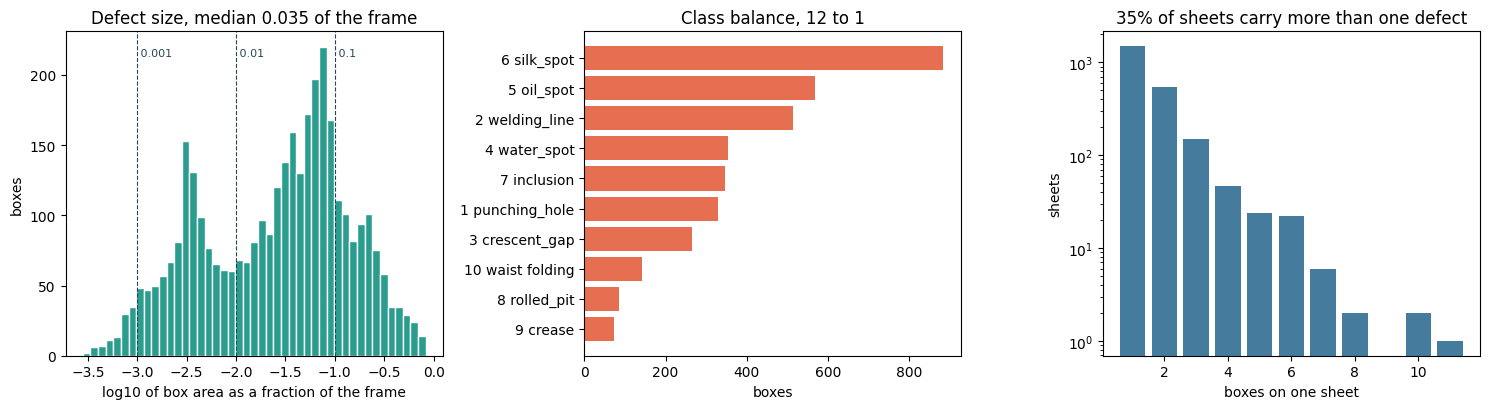

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(np.log10(geometry['area_fraction']), bins=45, color='#2a9d8f', edgecolor='white')
axes[0].set_xlabel('log10 of box area as a fraction of the frame')
axes[0].set_ylabel('boxes')
axes[0].set_title(f'Defect size, median {geometry["area_fraction"].median():.3f} of the frame')
for fraction in (0.001, 0.01, 0.1):
    axes[0].axvline(np.log10(fraction), color='#264653', lw=0.8, ls='--')
    axes[0].text(np.log10(fraction), axes[0].get_ylim()[1] * 0.95,
                 f' {fraction:g}', fontsize=8, color='#264653', va='top')

order = per_class.sort_values('boxes').index
axes[1].barh([f'{i} {per_class.loc[i, "english"]}' for i in order],
             per_class.loc[order, 'boxes'], color='#e76f51')
axes[1].set_xlabel('boxes')
axes[1].set_title(f'Class balance, {per_class["boxes"].max() / per_class["boxes"].min():.0f} to 1')

counts = per_image_boxes.value_counts().sort_index()
axes[2].bar(counts.index, counts.values, color='#457b9d')
axes[2].set_xlabel('boxes on one sheet')
axes[2].set_ylabel('sheets')
axes[2].set_yscale('log')
axes[2].set_title(f'{(per_image_boxes > 1).mean():.0%} of sheets carry more than one defect')

fig.tight_layout()
save_figure(fig, 'gc10_eda_overview', subfolder='cv')
plt.show()

## 9. How far a single pixel statistic gets

Every Arkon CV module measures the floor before it measures itself, because a
headline number means nothing without one. For a detector there is no
one-line baseline of the kind NEU has, so the floor measured here is the one that
is actually available: can mean brightness separate an image that contains a
given class from one that does not.

In [17]:
rng = np.random.default_rng(42)
subset = rng.choice(sorted(labelled['stem'].unique()), size=400, replace=False)
statistics = []
for stem in subset:
    array = np.asarray(Image.open(image_file[stem]), dtype=np.float32)
    statistics.append({'stem': stem, 'mean': array.mean(), 'std': array.std()})
statistics = pd.DataFrame(statistics).set_index('stem')
statistics['classes'] = [boxes_say[s] for s in statistics.index]

print(f'mean brightness over {len(statistics)} sheets: '
      f'{statistics["mean"].mean():.1f} +/- {statistics["mean"].std():.1f}')
print()
print('mean brightness of sheets carrying each class, against sheets that do not:')
shifts = {}
for class_id in sorted(per_class.index):
    has = statistics['classes'].apply(lambda ids: class_id in ids)
    if has.sum() < 10:
        continue
    difference = statistics.loc[has, 'mean'].mean() - statistics.loc[~has, 'mean'].mean()
    pooled = statistics['mean'].std()
    shifts[class_id] = abs(difference / pooled)
    print(f'  {class_id:2d} {per_class.loc[class_id, "english"]:<14} '
          f'n={int(has.sum()):3d}  difference {difference:+6.1f} grey levels '
          f'({difference / pooled:+.2f} pooled sd)')

strongest = max(shifts, key=shifts.get)
print()
print(f'largest shift: class {strongest} ({per_class.loc[strongest, "english"]}) at '
      f'{shifts[strongest]:.2f} pooled sd. '
      f'{sum(1 for v in shifts.values() if v < 0.4)} of {len(shifts)} classes are inside 0.4 sd.')

mean brightness over 400 sheets: 87.2 +/- 24.1

mean brightness of sheets carrying each class, against sheets that do not:
   1 punching_hole  n= 70  difference  +10.3 grey levels (+0.43 pooled sd)
   2 welding_line   n= 98  difference   -7.1 grey levels (-0.30 pooled sd)
   3 crescent_gap   n= 47  difference  -19.3 grey levels (-0.80 pooled sd)
   4 water_spot     n= 64  difference   -1.8 grey levels (-0.08 pooled sd)
   5 oil_spot       n= 40  difference   +5.4 grey levels (+0.22 pooled sd)
   6 silk_spot      n=126  difference   +3.9 grey levels (+0.16 pooled sd)
   7 inclusion      n= 31  difference   -0.3 grey levels (-0.01 pooled sd)
   8 rolled_pit     n= 15  difference   +6.9 grey levels (+0.29 pooled sd)
   9 crease         n= 12  difference   +4.7 grey levels (+0.19 pooled sd)
  10 waist folding  n= 20  difference   +8.8 grey levels (+0.36 pooled sd)

largest shift: class 3 (crescent_gap) at 0.80 pooled sd. 8 of 10 classes are inside 0.4 sd.


**Brightness shifts with the class and nowhere near enough to decide anything.**
The largest effect is crescent gap at 0.80 pooled standard deviations, which is a
real shift and still leaves the two distributions almost entirely on top of each
other; seven of the ten classes are inside 0.4 sd. The frame is a photograph of
steel and the defect occupies a median 3.5 per cent of it, so a whole-image
statistic averages the defect away by construction.

**The important half is that none of it localises.** Even a brightness rule that
worked would answer a different question from the one this module exists to
answer. Unlike NEU, where an untrained nearest-neighbour reaches 0.975 and the
headline number is mostly about the benchmark being easy, there is no cheap thing
that solves this one. The module's own numbers are the first real ones about this
dataset, so it has no free sanity check either, and section 4 of the model card
leans on the per-class counts instead.

## 10. What the images look like

Six sheets with their boxes drawn, chosen to show the range: the smallest defect
in the dataset, the largest, the most crowded sheet, and three classes that a
split will struggle to distribute.

  ✓ Saved → assets\cv\gc10_eda_samples.png


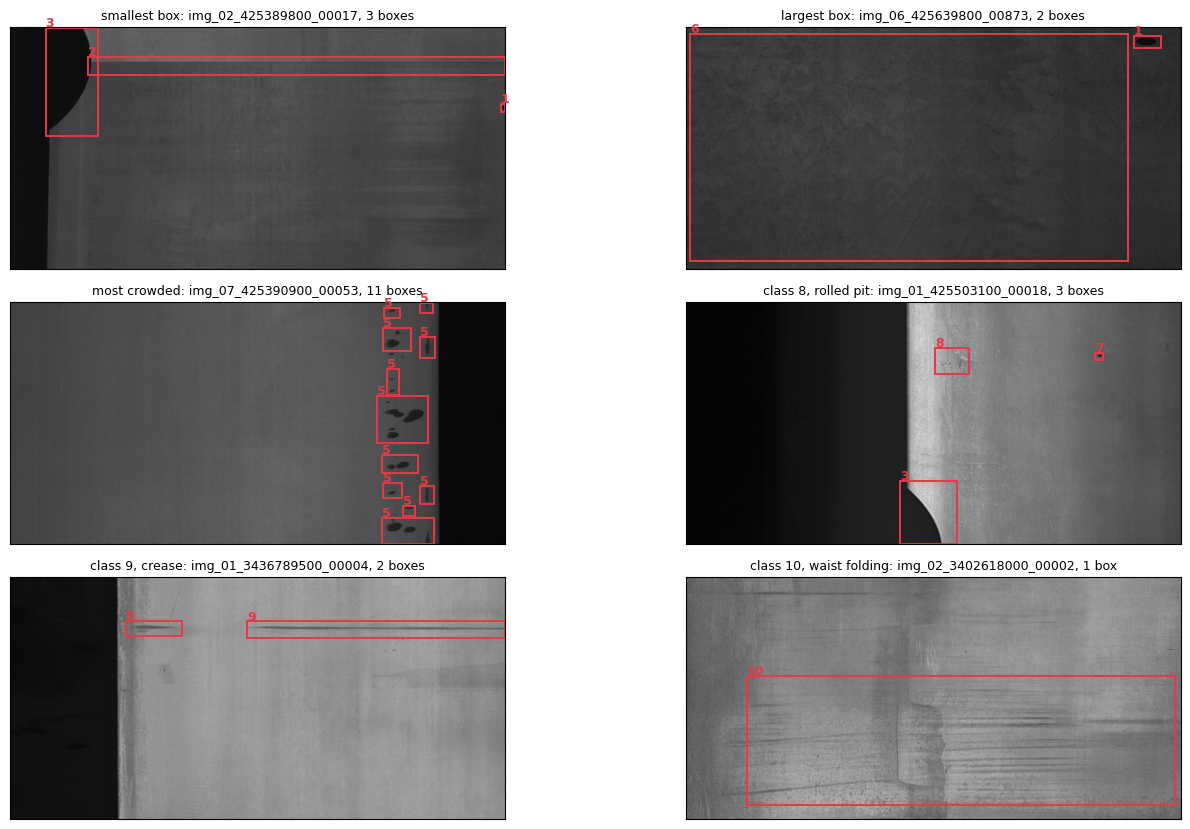

In [18]:
picks = [
    ('smallest box', geometry.loc[geometry['area_fraction'].idxmin(), 'stem']),
    ('largest box', geometry.loc[geometry['area_fraction'].idxmax(), 'stem']),
    ('most crowded', per_image_boxes.idxmax()),
    ('class 8, rolled pit', labelled.loc[labelled['class_id'] == 8, 'stem'].iloc[0]),
    ('class 9, crease', labelled.loc[labelled['class_id'] == 9, 'stem'].iloc[0]),
    ('class 10, waist folding', labelled.loc[labelled['class_id'] == 10, 'stem'].iloc[0]),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 8.4))
for ax, (label, stem) in zip(axes.ravel(), picks):
    ax.imshow(np.asarray(Image.open(image_file[stem])), cmap='gray', vmin=0, vmax=255)
    for _, row in labelled[labelled['stem'] == stem].iterrows():
        ax.add_patch(Rectangle((row['xmin'], row['ymin']),
                               row['xmax'] - row['xmin'], row['ymax'] - row['ymin'],
                               fill=False, color='#e63946', lw=1.4))
        ax.text(row['xmin'], row['ymin'] - 8, f'{row["class_id"]}',
                color='#e63946', fontsize=9, weight='bold')
    n = int((labelled['stem'] == stem).sum())
    ax.set_title(f'{label}: {stem}, {n} box{"es" if n != 1 else ""}', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
save_figure(fig, 'gc10_eda_samples', subfolder='cv')
plt.show()

## 11. What this notebook found

In [19]:
usable = len(folder_of_stem) - len(unusable)
print(f'1. {sum(len(v) for v in folder_of_stem.values()):,} image files carry '
      f'{len(folder_of_stem):,} distinct sheets: {len(duplicated)} are filed in two class '
      f'folders each.')
print(f'2. {len(unusable)} sheets carry no box, from two causes: '
      f'{len(missing_annotation)} have no annotation file and {len(empty_annotation)} have '
      f'an annotation with zero objects. Both are dropped rather than read as sound steel, '
      f'because this dataset contains no sheet anyone has certified clean.')
print(f'3. {usable:,} sheets carry {len(boxes):,} boxes. The shipped class key declares '
      f'{class_key["declared_boxes"].sum():,}. Nine classes agree exactly; the entire '
      f'{class_key["declared_boxes"].sum() - len(boxes)}-box shortfall is class 10, which the '
      f'annotations spell two ways where the key spells it one, plus one box tagged {"d"!r} '
      f'that matches no class.')
print(f'4. The folder is not a labelling. {len(multi_class):,} of {annotated:,} annotated sheets '
      f'({len(multi_class) / annotated:.1%}) carry a class their folder never names, and '
      f'{len(images) - xml_folder_agrees} annotation files contradict their own folder field. '
      f'The boxes are the label; the folder number is used for nothing after this notebook.')
print(f'5. The imbalance is {per_class["boxes"].max() / per_class["boxes"].min():.0f} to 1 in boxes '
      f'and {per_class["images"].max() / per_class["images"].min():.0f} to 1 in sheets, with class 9 '
      f'on {int(per_class.loc[9, "images"])} sheets. The split in notebook 02 is designed around '
      f'the rare classes, not the common ones.')
print(f'6. Defects are small on average and their scale is a class property: median '
      f'{geometry["area_fraction"].median():.4f} of a 2048 x 1000 frame overall, but the '
      f'per-class medians run {scale["median"].min():.4f} '
      f'({scale.loc[scale["median"].idxmin(), "name"]}) to {scale["median"].max():.4f} '
      f'({scale.loc[scale["median"].idxmax(), "name"]}), a factor of '
      f'{scale["median"].max() / scale["median"].min():.0f}. '
      f'{len(mostly_small)} classes sit mostly under 1 per cent of the frame and carry '
      f'{int(scale.loc[mostly_small, "boxes"].sum()):,} boxes, so any downscaling costs those '
      f'three and almost nothing else. Every image is the same size and single-channel, so the '
      f'channel is repeated three times for a pretrained backbone.')
print(f'7. {(per_image_boxes > 1).mean():.0%} of sheets carry more than one defect and one carries '
      f'{int(per_image_boxes.max())}. That is the measurement behind publishing one event per '
      f'sheet with the boxes inside the evidence object, rather than one event per box.')
print(f'8. Mean brightness shifts with the class but decides nothing: the largest effect is class '
      f'{strongest} at {shifts[strongest]:.2f} pooled sd and {sum(1 for v in shifts.values() if v < 0.4)} '
      f'of {len(shifts)} classes are inside 0.4 sd. Unlike NEU there is no cheap baseline to read '
      f'this module against, and no whole-image statistic answers the question it exists for, '
      f'which is where the defect is.')

1. 2,312 image files carry 2,300 distinct sheets: 12 are filed in two class folders each.
2. 8 sheets carry no box, from two causes: 6 have no annotation file and 2 have an annotation with zero objects. Both are dropped rather than read as sound steel, because this dataset contains no sheet anyone has certified clean.
3. 2,292 sheets carry 3,564 boxes. The shipped class key declares 3,570. Nine classes agree exactly; the entire 6-box shortfall is class 10, which the annotations spell two ways where the key spells it one, plus one box tagged 'd' that matches no class.
4. The folder is not a labelling. 476 of 2,292 annotated sheets (20.8%) carry a class their folder never names, and 88 annotation files contradict their own folder field. The boxes are the label; the folder number is used for nothing after this notebook.
5. The imbalance is 12 to 1 in boxes and 16 to 1 in sheets, with class 9 on 53 sheets. The split in notebook 02 is designed around the rare classes, not the common ones.
6